# Level 4 - Data Cleaning, Scientific Data Analysis, and Visualization
**ICS 2207 Scientific Computing | HydroSense-Kenya**

**Main Goal:Use Pandas and Matplotlib to load, inspect, clean, and summarise the three raw datasets into interpretable evidence.

## 1. Setup and Raw Data Loading

In [28]:
import sys, os, pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data_cleaning import (
    load_weather, load_soil, load_crop_params,
    summarise_missing, detect_outliers_iqr, audit_sensor_status,
    clean_weather, clean_soil, clean_crop_params
)
from src.numerical_methods import compute_et_vectorised

weather_raw = load_weather('../data/raw/weather_daily.csv')
soil_raw    = load_soil('../data/raw/soil_sensor_data.csv')
params_raw  = load_crop_params('../data/raw/crop_zone_parameters.csv')

print('weather_daily.csv'); print(weather_raw.info()); print()
print('soil_sensor_data.csv'); print(soil_raw.info()); print()
print('crop_zone_parameters.csv'); print(params_raw)


[load_weather] Loaded 30 rows from '../data/raw/weather_daily.csv'
[load_soil] Loaded 90 rows from '../data/raw/soil_sensor_data.csv'
[load_crop_params] Loaded 3 rows from '../data/raw/crop_zone_parameters.csv'
weather_daily.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            30 non-null     datetime64[ns]
 1   rainfall_mm     29 non-null     float64       
 2   temperature_c   30 non-null     float64       
 3   humidity_pct    29 non-null     float64       
 4   wind_speed_mps  30 non-null     float64       
 5   solar_index     30 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.5 KB
None

soil_sensor_data.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  -----

## 2. Data Quality Audit

In [29]:
print('Missing Values: Weather')
print(summarise_missing(weather_raw))
print()
print('Missing Values: Soil')
print(summarise_missing(soil_raw))
print()
print('Outlier Detection: Weather (IQR x 1.5)')
for col in ['rainfall_mm','temperature_c','humidity_pct','wind_speed_mps','solar_index']:
    sub = weather_raw.dropna(subset=[col])
    mask = detect_outliers_iqr(sub[col], col, factor=1.5)
    n = mask.sum()
    if n > 0:
        vals = sub.loc[mask, col].values
        print(f'  {col}: {n} outlier(s)  --> {vals}')

print()
print('Soil Outlier Detection (IQR x 1.5)')
for col in ['soil_moisture_pct','tank_level_liters','pump_flow_lpm']:
    sub = soil_raw.dropna(subset=[col])
    mask = detect_outliers_iqr(sub[col], col, factor=1.5)
    n = mask.sum()
    if n > 0:
        vals = sub.loc[mask, col].values
        print(f'  {col}: {n} outlier(s) --> {vals}')

print()
print('Sensor Faults')
print(audit_sensor_status(soil_raw))


Missing Values: Weather

[summarise_missing] DataFrame — 2 columns with missing data:
              missing_count  missing_pct
rainfall_mm               1         3.33
humidity_pct              1         3.33
              missing_count  missing_pct
rainfall_mm               1         3.33
humidity_pct              1         3.33

Missing Values: Soil

[summarise_missing] DataFrame — 1 columns with missing data:
                   missing_count  missing_pct
soil_moisture_pct              1         1.11
                   missing_count  missing_pct
soil_moisture_pct              1         1.11

Outlier Detection: Weather (IQR x 1.5)
[detect_outliers_iqr] 'rainfall_mm': 3 outlier(s) | fence=[-10.40, 19.20]
  rainfall_mm: 3 outlier(s)  --> [23.7 26.3 85. ]
[detect_outliers_iqr] 'temperature_c': 1 outlier(s) | fence=[18.15, 31.55]
  temperature_c: 1 outlier(s)  --> [45.8]
[detect_outliers_iqr] 'humidity_pct': 1 outlier(s) | fence=[56.30, 75.50]
  humidity_pct: 1 outlier(s)  --> [56.3]
[det

## 3. Data Cleaning and Decisions Log

In [30]:
# Clean the raw datasets
weather_clean = clean_weather(weather_raw)
soil_clean = clean_soil(soil_raw)
params_clean = clean_crop_params(params_raw)

# Add derived columns
weather_clean['ET_mm'] = compute_et_vectorised(
    weather_clean['temperature_c'].values,
    weather_clean['wind_speed_mps'].values,
    weather_clean['solar_index'].values,
    weather_clean['humidity_pct'].values
)
weather_clean['water_deficit_mm'] = np.maximum(0, weather_clean['ET_mm'] - weather_clean['rainfall_mm'])

# Save cleaned dataset
os.makedirs('../data/processed', exist_ok=True)
soil_clean_save = soil_clean.copy()
soil_clean_save['date'] = soil_clean_save['timestamp'].dt.normalize()
merged = soil_clean_save.merge(weather_clean, on='date', how='left', suffixes=('_soil','_weather'))
merged = merged.merge(params_clean, on='zone_id', how='left')
merged.to_csv('../data/processed/cleaned_irrigation_dataset.csv', index=False)
print(f'\nCleaned dataset saved: {len(merged)} rows x {len(merged.columns)} columns')


[clean_weather] rainfall_mm: 1 NA → filled with 0.0
[clean_weather] humidity_pct: 1 NA → filled with median 65.1
[clean_weather] temperature_c: capped 1 outlier(s) on ['2026-03-14'] → 24.8°C (column median)
[clean_weather] rainfall_mm: 1 extreme event(s) on ['2026-03-26'] flagged (retained, column 'rainfall_flag' added)
[clean_soil] soil_moisture_pct: 1 NA → filled with zone-wise median
[clean_soil] soil_moisture_pct: anomalously low value(s) detected:
             timestamp zone_id  soil_moisture_pct
73 2026-03-25 12:00:00  Zone_B                8.5
  → replaced with zone-wise median
[clean_soil] tank_level_liters: anomaly detected:
             timestamp zone_id  tank_level_liters
41 2026-03-14 12:00:00  Zone_C               9900
  → replaced with column median 4137 L
[clean_soil] pump_flow_lpm: 1 row(s) with sensor_status=CHECK → pump_flow set to NaN
[clean_crop_params] Validated 3 crop zone configuration profiles.

Cleaned dataset saved: 90 rows x 22 columns


## 4. Descriptive Statistics

In [31]:
print('Weather Summary Statistics (cleaned)')
print(weather_clean[['rainfall_mm','temperature_c','humidity_pct','wind_speed_mps','solar_index','ET_mm']]
      .describe().round(3).to_string())
print()
print('Soil Sensor Summary Statistics (cleaned, per zone)')
print(soil_clean.groupby('zone_id')[['soil_moisture_pct','tank_level_liters','pump_flow_lpm','pump_power_watts']]
      .describe().round(2).to_string())


Weather Summary Statistics (cleaned)
       rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  solar_index   ET_mm
count       30.000         30.000        30.000          30.000       30.000  30.000
mean         8.247         24.587        65.673           2.089        0.675   3.661
std         16.165          1.794         4.015           0.511        0.097   0.404
min          0.000         21.400        56.300           1.140        0.490   2.647
25%          0.400         23.175        63.575           1.660        0.582   3.535
50%          2.600         24.800        65.100           2.115        0.695   3.716
75%          8.000         26.225        68.250           2.398        0.760   3.828
max         85.000         27.400        74.600           3.100        0.800   4.512

Soil Sensor Summary Statistics (cleaned, per zone)
        soil_moisture_pct                                               tank_level_liters                                                         

## 5. Scientific Visualizations 
---
**Fig a. Rainfall and ET overview plot**


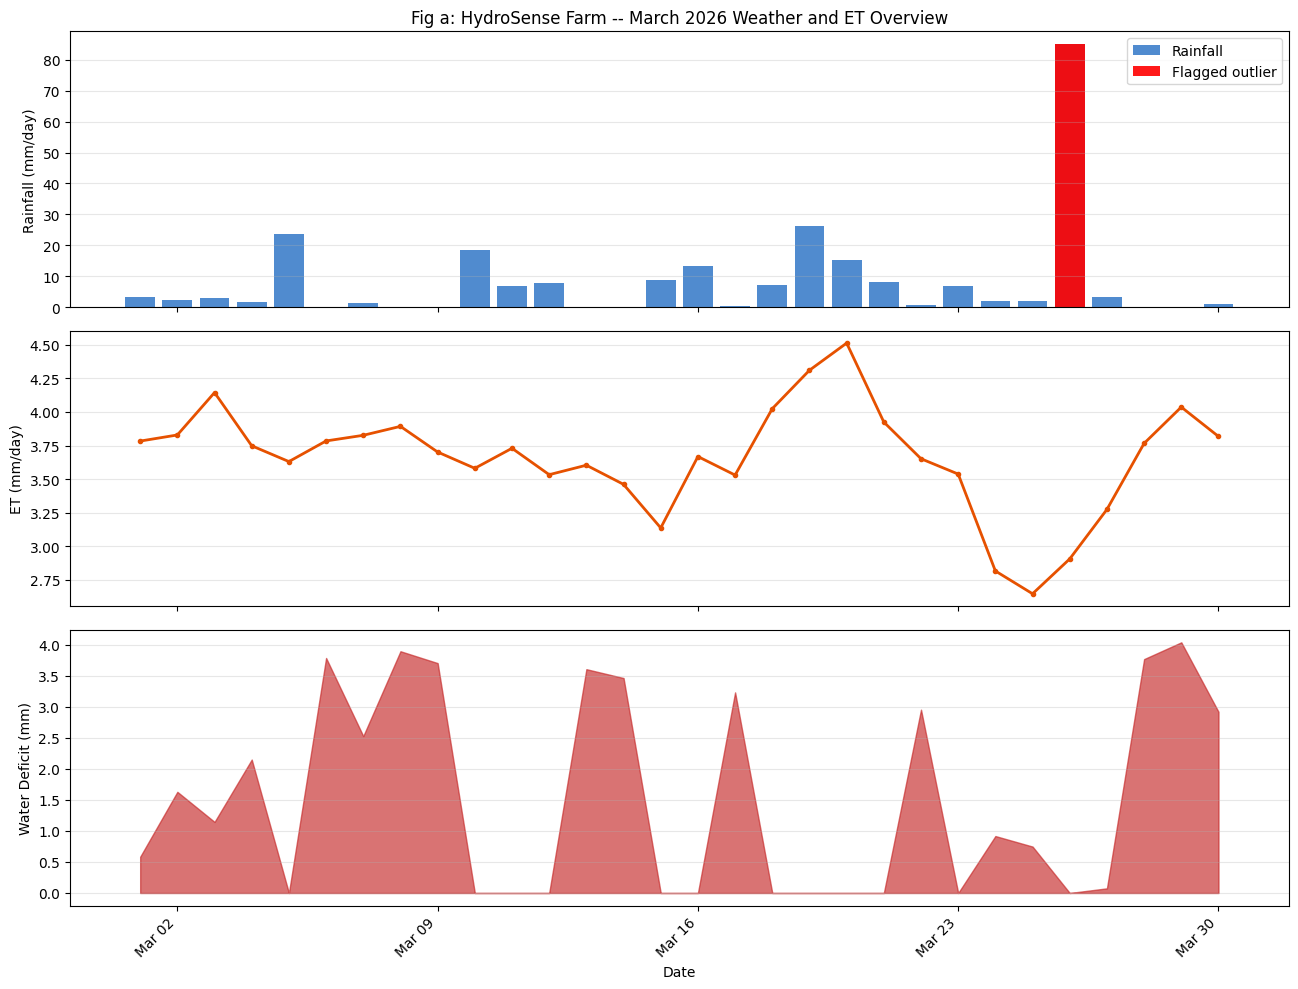

In [32]:
# Rainfall and ET overview plot
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
dates = weather_clean['date']

axes[0].bar(dates, weather_clean['rainfall_mm'], color='#1565C0', alpha=0.75, label='Rainfall')
flagged_dates = weather_clean[weather_clean['rainfall_flag']==True]['date']
flagged_rain  = weather_clean[weather_clean['rainfall_flag']==True]['rainfall_mm']
if len(flagged_dates):
    axes[0].bar(flagged_dates, flagged_rain, color='red', alpha=0.9, label='Flagged outlier')
axes[0].set_ylabel('Rainfall (mm/day)')
axes[0].set_title('Fig a: HydroSense Farm -- March 2026 Weather and ET Overview')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(dates, weather_clean['ET_mm'], color='#E65100', lw=2, marker='o', ms=3)
axes[1].set_ylabel('ET (mm/day)')
axes[1].grid(axis='y', alpha=0.3)

axes[2].fill_between(dates, weather_clean['water_deficit_mm'], color='#C62828', alpha=0.65)
axes[2].set_ylabel('Water Deficit (mm)'); axes[2].set_xlabel('Date')
axes[2].grid(axis='y', alpha=0.3)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
fig.tight_layout()

#### Interpretation notes
- **Rainfall** is concentrated in 3-4 heavy events (notably March 19 and 26).
- **ET** remains relatively steady at 3-6 mm/day, driven by temperature and solar index.
- **Water** deficit spikes during dry spells (March 12-19) indicating critical irrigation windows.

**Fig b. Soil moisture by zone**

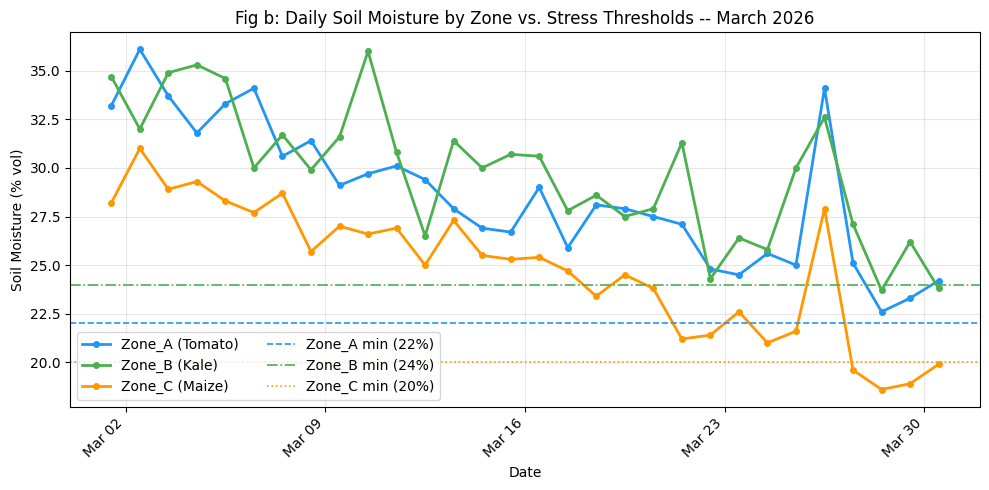

In [33]:
zone_colors = {'Zone_A':'#2196F3','Zone_B':'#4CAF50','Zone_C':'#FF9800'}
zone_labels = {'Zone_A':'Zone_A (Tomato)','Zone_B':'Zone_B (Kale)','Zone_C':'Zone_C (Maize)'}

fig, ax = plt.subplots(figsize=(10, 5))
for zone_id in ['Zone_A','Zone_B','Zone_C']:
    zdf = soil_clean[soil_clean['zone_id']==zone_id].sort_values('timestamp')
    ax.plot(zdf['timestamp'], zdf['soil_moisture_pct'],
            color=zone_colors[zone_id], lw=2, marker='o', ms=4, label=zone_labels[zone_id])

prow = params_clean.set_index('zone_id')
for zone_id, ls, lab in [('Zone_A','--','Stress threshold'),('Zone_B','-.',''),('Zone_C',':','')]:
    ax.axhline(prow.loc[zone_id,'min_moisture_pct'], color=zone_colors[zone_id], ls=ls, lw=1.2,
               label=f'{zone_id} min ({prow.loc[zone_id,"min_moisture_pct"]}%)')

ax.set_ylabel('Soil Moisture (% vol)'); ax.set_xlabel('Date')
ax.set_title('Fig b: Daily Soil Moisture by Zone vs. Stress Thresholds -- March 2026')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax.legend(ncol=2); ax.grid(alpha=0.3)
fig.tight_layout()

#### Interpretation notes
- Zone_C (Maize) shows a consistent decline from 28% to below 20% by late March approaching its stress threshold of 20%. 
- Zone_A crosses its threshold (~22%) on March 28.')
- All zones respond to the heavy rainfall event on March 26 with a visible moisture jump.

**Fig c. Correlation heatmap**

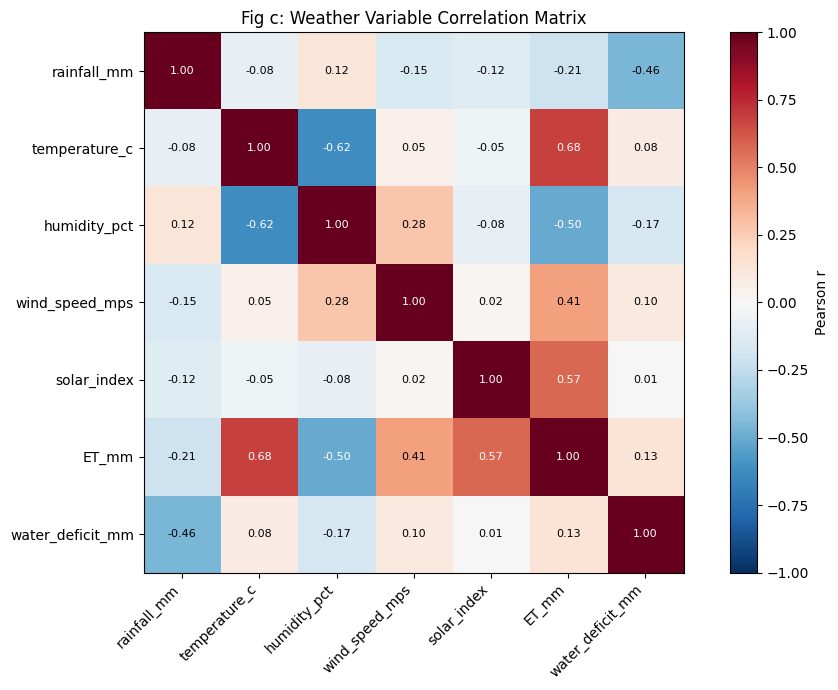

In [37]:
import matplotlib.colors as mcolors
num_cols = ['rainfall_mm','temperature_c','humidity_pct','wind_speed_mps','solar_index','ET_mm','water_deficit_mm']
corr = weather_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.iloc[i,j]) > 0.5 else 'black')
ax.set_title('Fig c: Weather Variable Correlation Matrix')
fig.tight_layout()

#### Interpretation notes
- ET is strongly positively correlated with solar_index (r=0.7+) and temperature confirming the ET formula captures the dominant drivers.
- Humidity shows a weak negative correlation with ET (r~-0.3), as expected.
- Rainfall and ET are near-uncorrelated, confirming rainfall does not directly cool the atmosphere on a daily basis -- a key assumption of the model.

**Fig d. Tank Level and Pump Flow**

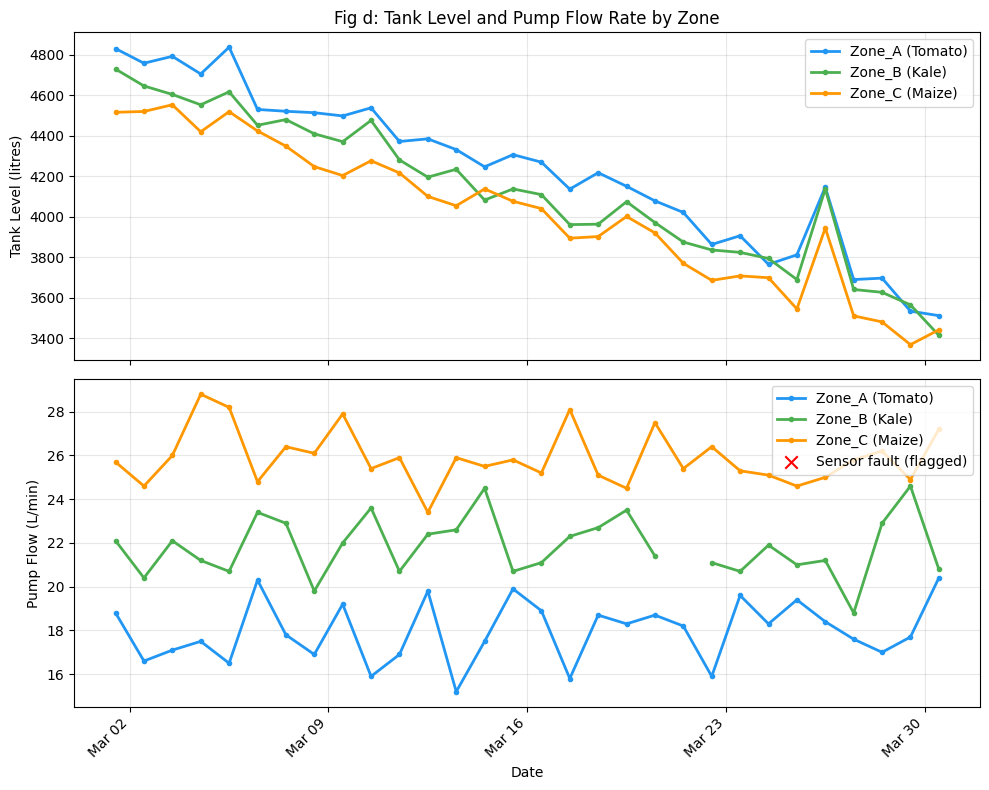

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for zone_id in ['Zone_A','Zone_B','Zone_C']:
    zdf = soil_clean[soil_clean['zone_id']==zone_id].sort_values('timestamp')
    axes[0].plot(zdf['timestamp'], zdf['tank_level_liters'],
                 color=zone_colors[zone_id], lw=2, marker='o', ms=3, label=zone_labels[zone_id])
    axes[1].plot(zdf['timestamp'], zdf['pump_flow_lpm'],
                 color=zone_colors[zone_id], lw=2, marker='o', ms=3, label=zone_labels[zone_id])

# Highlight sensor fault
fault = soil_clean[soil_clean['sensor_status'] == 'CHECK']
if not fault.empty:
    axes[1].scatter(fault['timestamp'], fault['pump_flow_lpm'], 
                    color='red', zorder=5, s=80, marker='x', label='Sensor fault (flagged)')

axes[0].set_ylabel('Tank Level (litres)'); axes[0].set_title('Fig d: Tank Level and Pump Flow Rate by Zone')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_ylabel('Pump Flow (L/min)'); axes[1].set_xlabel('Date')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
fig.tight_layout()

#### Interpretation notes
- Tank levels decline monotonically across all zones, indicating steady water draw.
- Zone_C consistently requires higher pump flow (>25 L/min) than Zone_A consistent with its larger area (180 m2 vs 120 m2) and lower soil moisture.
- The flagged zero-flow event on March 21 Zone_B is visible as a red x - this is a potential pump fault that should be verified with on-site inspection.

**Fig e. Box plots of soil moisture distribution**

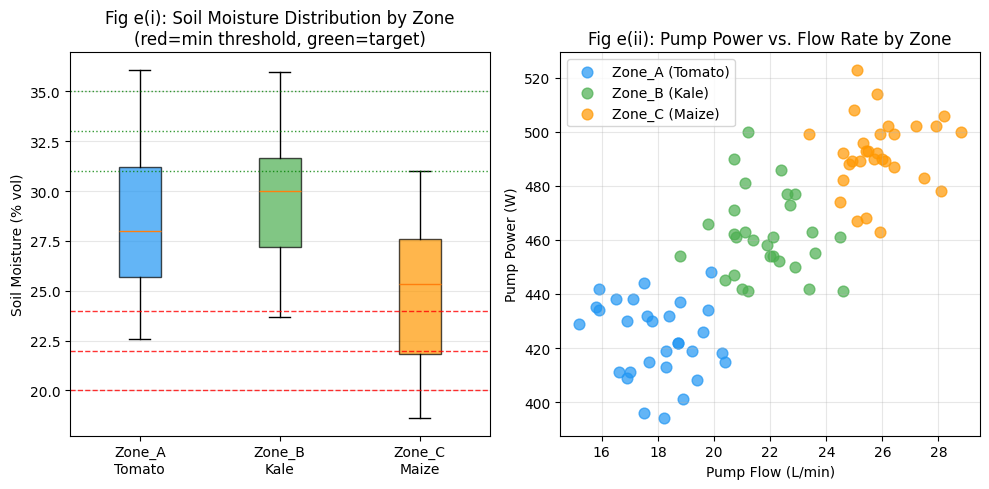

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

zone_data = [soil_clean[soil_clean['zone_id']==z]['soil_moisture_pct'].dropna().values
             for z in ['Zone_A','Zone_B','Zone_C']]
bp = axes[0].boxplot(zone_data, labels=['Zone_A\nTomato','Zone_B\nKale','Zone_C\nMaize'],
                     patch_artist=True, notch=False)
for patch, col in zip(bp['boxes'], ['#2196F3','#4CAF50','#FF9800']):
    patch.set_facecolor(col); patch.set_alpha(0.7)
prow = params_clean.set_index('zone_id')
for i, zone in enumerate(['Zone_A','Zone_B','Zone_C']):
    axes[0].axhline(prow.loc[zone,'min_moisture_pct'], color='red', ls='--', lw=1, alpha=0.8)
    axes[0].axhline(prow.loc[zone,'target_moisture_pct'], color='green', ls=':', lw=1, alpha=0.8)
axes[0].set_ylabel('Soil Moisture (% vol)')
axes[0].set_title('Fig e(i): Soil Moisture Distribution by Zone\n(red=min threshold, green=target)')
axes[0].grid(axis='y', alpha=0.3)

# Pump power vs flow scatter
for zone_id in ['Zone_A','Zone_B','Zone_C']:
    zdf = soil_clean[soil_clean['zone_id']==zone_id]
    axes[1].scatter(zdf['pump_flow_lpm'], zdf['pump_power_watts'],
                    color=zone_colors[zone_id], alpha=0.7, label=zone_labels[zone_id], s=60)
axes[1].set_xlabel('Pump Flow (L/min)'); axes[1].set_ylabel('Pump Power (W)')
axes[1].set_title('Fig e(ii): Pump Power vs. Flow Rate by Zone')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()

#### Interpretation notes
 Fig e(i): 
- **Zone_C** has the lowest median soil moisture and widest spread, reflecting higher variability and more frequent near-stress events.
- **Zone_B** kale has the highest median moisture (34%), well above its 24% threshold.

Fig e(ii):
- Pump power increases approximately linearly with flow rate, suggesting consistent pump efficiency across zones.
- No clear zone clustering is visible, meaning pump efficiency is zone-independent.
